# Data Challenge 8 — Introduction to Multiple Linear Regression (MLR)


**Format:** Instructor Guidance → You Do (Students) → We Share (Reflection)


**Goal:** Build an **MLR** model using **2–3 predictors** to predict one numeric target. Evaluate with a **train–test split** (MAE/RMSE), interpret **coefficients while holding others constant**, and compare against an **SLR baseline**.


> Dataset: **NYC Yellow Taxi — Dec 2023** (CSV). Keep code *simple*: light numeric coercion only for your chosen columns.

## Instructor Guidance

**Docs (quick links):**
- Train/Test Split — scikit‑learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- MAE / MSE / RMSE — scikit‑learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
- OLS (fit/predict/residuals) — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html
- OLS Results (`resid`, `fittedvalues`, `summary`) — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html
- Q–Q plot — SciPy: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html


### Pseudocode Plan (for **MLR**)
1) **Load CSV** → preview columns/shape.
2) **Assign Y and Xs (2–3 predictors)** → pick numeric columns that matter; if needed, coerce **just** these to numeric and drop NAs.
3) **Add intercept** → `X = add_constant(X_matrix)`.
4) **Train–test split (80/20)** → `X_train, X_test, y_train, y_test = train_test_split(...)` (set `random_state`).
5) **Fit on TRAIN** → `model = OLS(y_train, X_train).fit()`.
6) **Predict on TEST** → `y_pred = model.predict(X_test)`.
7) **Evaluate on TEST** → compute **MAE** and **RMSE** using `y_test` & `y_pred`; speak in **units of Y**.
8) **Diagnostics on TRAIN** → use `model.resid` & `model.fittedvalues` for residuals vs fitted; Q–Q plot; check Durbin–Watson in `model.summary()`.
9) **Bias–variance read (optional)** → compare train vs test errors.
10) **Stakeholder one‑liner** → MAE/RMSE in units + brief reliability note. *(Optional)* Contrast with an **SLR baseline** using the strongest single predictor.

## You Do — Student Section
Work in pairs. Keep code simple and comment your choices.

### Step 0 — Setup & Imports

In [51]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### Step 1 — Load CSV & Preview
- Point to your **Dec 2023** taxi CSV.
- Print **shape** and **columns**.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [52]:
df = pd.read_csv("/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/2023_Yellow_Taxi_Trip_Data_20251015.csv", low_memory=False)

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], format="%m/%d/%Y %H:%M:%S %p")

# Creates a new column 'hour' with the hour extracted
df['hour'] = df['tpep_pickup_datetime'].dt.hour


# Keep only numeric and relevant columns
num_cols = ['fare_amount', 'trip_distance', 'passenger_count','tip_amount','hour']

df = df.dropna()
for c in num_cols:
    df[c] = pd.to_numeric (
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
)


# Data had too many outliers, fares of upwards too 300,000 and negative fares too
df = df[
    (df['fare_amount'] > 0) &               # remove negative/zero fares
    (df['fare_amount'] < 250) &             # cap at $250 (reasonable max)
    (df['trip_distance'] > 0) &             # remove zero/negative distances
    (df['trip_distance'] < 100) &           # cap distance
    (df['passenger_count'] > 0) &           # must have passengers
    (df['passenger_count'] < 7)             # standard NYC cab limit
].copy()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,hour
0,2,2023-12-01 04:11:39,12/01/2023 04:19:13 PM,2.0000,0.6900,1.0000,N,141,140,1,7.9000,2.5000,0.5000,3.0000,0.0000,1.0000,17.4,2.5000,0.0000,4
1,1,2023-12-01 04:11:39,12/01/2023 04:20:41 PM,3.0000,1.1000,1.0000,N,236,263,2,10.0000,5.0000,0.5000,0.0000,0.0000,1.0000,16.5,2.5000,0.0000,4
3,2,2023-12-01 04:11:39,12/01/2023 04:20:38 PM,1.0000,1.5700,1.0000,N,48,239,4,10.7000,2.5000,0.5000,0.0000,0.0000,1.0000,17.2,2.5000,0.0000,4
4,1,2023-12-01 04:11:39,12/01/2023 04:34:39 PM,2.0000,3.0000,1.0000,N,164,211,1,21.9000,5.0000,0.5000,3.0000,0.0000,1.0000,31.4,2.5000,0.0000,4
6,2,2023-12-01 04:11:40,12/01/2023 04:23:51 PM,1.0000,1.2400,1.0000,N,142,162,4,11.4000,2.5000,0.5000,0.0000,0.0000,1.0000,17.9,2.5000,0.0000,4


<Axes: xlabel='hour', ylabel='fare_amount'>

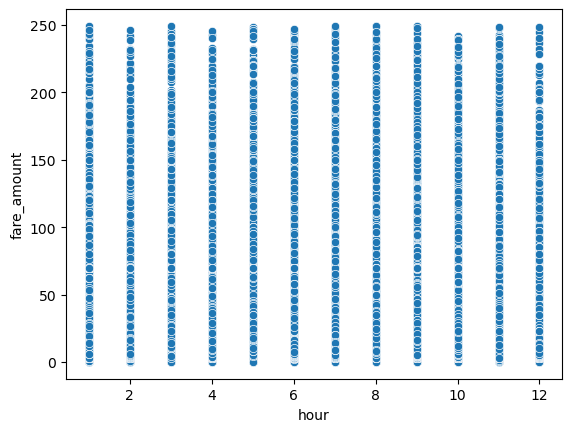

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a basic scatterplot
sns.scatterplot(x="hour", y="fare_amount", data=df)

### Step 2 —  Pick Target **Y** and Predictors **Xs** (choose 2–3 numeric)

- **Avoid** using an X that directly defines Y (e.g., `total_amount` when Y = `fare_amount`).
- Coerce **only these columns** to numeric; drop NA rows.

In [54]:
Y = df['fare_amount']

X = sm.add_constant(df[['trip_distance','hour']])


### Step 3 —  Design Matrix (add intercept) & Train–Test Split (80/20)

- Add intercept with `sm.add_constant`.
- Use a **random_state** for reproducibility.
- (Optional) Discuss when a **time‑aware** split is better.

In [55]:
from sklearn.linear_model import LinearRegression


X_train, X_test, y_train, y_test = train_test_split(X,Y, random_state=42, train_size=.80)



model = LinearRegression()
model.fit(X_train,y_train)
print(X_train.shape, X_test.shape)


(2412250, 3) (603063, 3)


### Step 4 — Fit MLR on TRAIN & Interpret Coefficients (holding others constant)

- Print the **coefficient table**.
- Write **one unit‑based sentence per coefficient** using “**holding others constant**.”

In [56]:
coefficients = model.coef_
feature_names = X.columns.tolist()

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
print("Regression Coefficients:")
print(coef_df)
print(f"\nIntercept: {model.intercept_}")
print(f"R-squared score: {model.score(X, Y)}")

Regression Coefficients:
         Feature  Coefficient
0          const       0.0000
1  trip_distance       3.6850
2           hour      -0.1019

Intercept: 8.205946461659588
R-squared score: 0.8682685423987534


/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


*Template (edit to your variables & units):*
- **β_intercept (const):** 8.2, this means that when the trip begins and hour is 0 (midnight) the predicted base fare is $8.2
- **β_X1:** Holding other predictors constant, +1 unit in **trip_distance** is associated with **+3.7** units in **fare_amount**.
- **β_X2:** Holding other predictors constant, +1 unit in **hour** is associated with **-0.1** units in **fare_amount**.
- *(If 3rd predictor)* **β_X3:** …
- **Significance:** Note **p‑values** and **95% CIs** (from statsmodels summary) if relevant.
- p_value: <0.00 
- 95% CI:
- - trip_distance: (3.683,3.687)
- - hour: (-0.104,-0.100)

### Step 5 — Evaluate on **Unseen Test Data** (MAE/RMSE in units of Y)
Compute MAE and RMSE and write a one‑sentence **stakeholder** readout.

In [57]:
model = sm.OLS(y_train, X_train).fit()
y_pred = model.predict(X_test)


mae_val = mean_absolute_error(y_test, y_pred)
rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))

print(mae_val)
print(rmse_val)

3.643722693000517
6.335466658985362


The difference between y_actual and y_predicted is about $3.66

### Step 6 — (Optional) Compare to an SLR Baseline
- Fit **SLR** using your strongest single predictor (e.g., `trip_distance`).
- Compare **MAE/RMSE** to your **MLR**; explain why MLR helped (or didn’t).

In [58]:
# SLR 
Y = df['fare_amount']
X2 = sm.add_constant(df['trip_distance'])
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,Y, random_state=42, train_size=.80)
model2 = LinearRegression()
model2.fit(X2_train,y2_train)
model2 = sm.OLS(y2_train, X2_train).fit()
y2_pred = model2.predict(X2_test)
mae2_val = mean_absolute_error(y2_test, y2_pred)
rmse2_val = np.sqrt(mean_squared_error(y2_test, y2_pred))

print('MLR MAE:',mae_val,'\nMLR RMSE:',rmse_val)
print('\nSLR MAE:',mae2_val,'\nSLR RMSE:',rmse2_val)


MLR MAE: 3.643722693000517 
MLR RMSE: 6.335466658985362

SLR MAE: 3.6539772622100553 
SLR RMSE: 6.344727563733905


MAE and RMSE are about the same for both SLR and MLR. Could be that hour of day has little to none effect on fare_amount. 

### Step 7 — Quick Diagnostics (Train Residuals)
- **Residuals vs Fitted:** random cloud ≈ good; cones/funnels suggest non‑constant variance.
- **Q–Q plot:** points roughly along diagonal (normality for inference).
- **Durbin–Watson:** printed in `model.summary()` (~2 suggests independence).

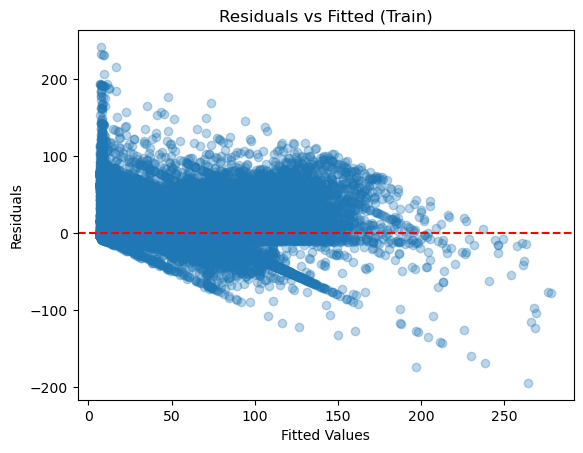

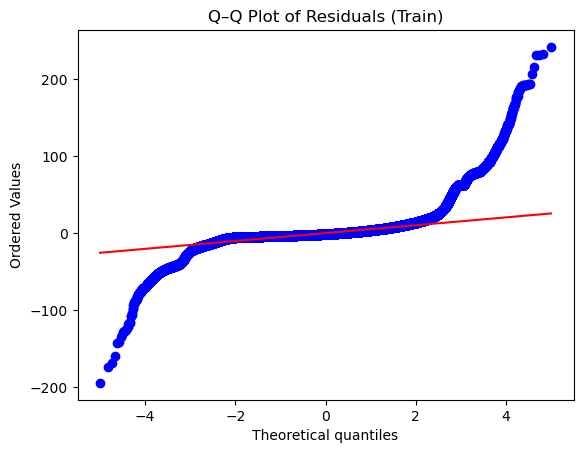

In [59]:
residuals = model.resid
fitted = model.fittedvalues

plt.scatter(fitted, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted (Train)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# Q–Q plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals (Train)")
plt.show()

In [60]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                 7.979e+06
Date:                Tue, 04 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:21:00   Log-Likelihood:            -7.8645e+06
No. Observations:             2412250   AIC:                         1.573e+07
Df Residuals:                 2412247   BIC:                         1.573e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.2059      0.010    855.863

## We Share — Reflection & Wrap‑Up
Write **2 short paragraphs** and be specific:


1) **Which model would you trust today—MLR or SLR—and why?**
Use **test MAE/RMSE (units)**, coefficient interpretations (holding others constant), and any residual/correlation observations.


2) **What’s next to improve reliability?**
Options: add a more relevant predictor, use a **time‑aware split**, segment by ride type (airport vs. city), or prepare for **VIF/regularization** to handle collinearity.

- 1. I would trust the simple linear regression (SLR) model more for now. Both the MLR and SLR had almost the same MAE and RMSE, which means adding hour didn’t really improve the model’s accuracy. The relationship between trip_distance and fare_amount was strong and made sense, the farther you go, the more you pay. The hour of the day, on the other hand, barely changed the fare and didn’t add much value. Since the simpler model performs just as well with fewer inputs, it’s the more reliable choice at this stage
- 2. To make the model more accurate and realistic, I’d look at adding other predictors that actually affect fares, like trip duration, pickup or drop-off location, or whether the trip was to or from the airport. Using a time-aware train-test split might also help if we care about predicting future fares. The next step is to give the model better information so it can make smarter predictions.